In [1]:
import sys
import time
from pathlib import Path

import numpy as np

ROOT = Path.cwd()
if not (ROOT / "eos").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt

from eos import alphabag, ccdm, njl, vmit
from eos.ccdm.table import rows_from_result as ccdm_rows_from_result
from eos.general.figure_style import (LABELS, OKAB_CAT, log_decades,
                                      panel_label, paper_grid,
                                      particle_style)
from eos.general.table_io import matrix_from_rows
from eos.njl.table import rows_from_result as njl_rows_from_result

# Name -> package. Every model exposes the same entry points under the same
# names — `Parameters`, `SpeciesFlags`, `eos_point`, `eos_table` — so one loop
# body serves all four. `rows_from_result` is the one that is not uniform:
# `vmit` and `alphabag` re-export it from the package, `njl` and `ccdm` leave it
# in their `table` module, so it is looked up here once rather than branched on
# inside the loop.
MODELS = {"vmit": vmit, "alphabag": alphabag, "njl": njl, "ccdm": ccdm}
ROWS_FROM_RESULT = {"vmit": vmit.rows_from_result,
                    "alphabag": alphabag.rows_from_result,
                    "njl": njl_rows_from_result,
                    "ccdm": ccdm_rows_from_result}

## One T = 0 beta-equilibrium line, per model

The quark counterpart of `hadronic_timing`: four models of deconfined matter
driven through the same public entry points, in the same mode, on the same
density grid, and timed the same way.

The sectors are the six names of CLAUDE.md section 4, spelled identically in
every model, plus `csc` — the pairing sector, which exists only where the
functional has it. `vmit` and `alphabag` carry no such field, so passing it
would be a `TypeError`, which is this notebook's own bug and not a model
refusing anything; the flag is therefore added per model rather than shared.

`muons` is off for all four, and that is a gap rather than a choice: `njl` and
`ccdm` wire the muon family, `vmit` and `alphabag` do not and raise if asked.
One shared value is what keeps all four models in the same figures.

In [2]:
# The six section-4 names, identical in every model.
SPECIES = dict(hyperons=False, deltas=False, muons=False,
               thermal_mesons=False, thermal_neutrinos=False, photons=False)

# `csc` only where the pairing sector is in the functional. False everywhere:
# this notebook is unpaired quark matter.
CSC = {"njl": False, "ccdm": False}

# The published set each model is driven at; None = Parameters.default().
#   vmit, alphabag  ship exactly one set each, so there is nothing to name.
#   njl             "rkh" is the shipped default — the set every verified number
#                   in the model's documentation was produced at and the one
#                   test/baseline is frozen at.
#   ccdm            "baseline" is the specification's own baseline set, likewise
#                   the shipped default. Its deconfinement onset sits just below
#                   1 fm^-3, well inside the grid below, which is the point:
#                   the densities underneath it come back unsolved and that is
#                   physics about the model, not a solver failure.
PARAMETER_SET = {"vmit": None, "alphabag": None,
                 "njl": "rkh", "ccdm": "baseline"}

# 0.1 to 1.6 fm^-3. The top is a few times saturation, which is where a hybrid
# star's quark core lives; the bottom is deliberately below any of these phases
# being the physical state, so `ccdm`'s onset shows up as refusals in the count
# rather than being hidden by a grid chosen to flatter it.
N_B = np.linspace(0.1, 1.6, 60)
T = 0.0

TABLES = {}          # {model: rows}, read by every figure below
PARAMS = {}          # {model: par}, read by the effective-mass figure

print(f"=== one line, beta_eq_neutrinoless, T = {T} MeV, "
      f"{len(N_B)} points from {N_B[0]:.3f} to {N_B[-1]:.3f} fm^-3 ===")

for name, module in MODELS.items():
    published = PARAMETER_SET[name]
    par = (module.Parameters.default() if published is None
           else module.Parameters.named(published))

    # A model that does not have one of the selected sectors refuses — at flag
    # construction where the sector is absent from the functional, inside
    # `eos_point` where the mode is not one this phase has. Both are the
    # library's contract working, so they are printed and skipped, never dressed
    # up as a result. `TypeError` is deliberately not caught: an unexpected
    # keyword is this notebook's own bug.
    try:
        species = module.SpeciesFlags(
            **SPECIES, **({"csc": CSC[name]} if name in CSC else {}))

        start = time.perf_counter()
        point = module.eos_point(par, "beta_eq_neutrinoless", species,
                                 n_B=float(N_B[0]), T=T)
        first_s = time.perf_counter() - start

        start = time.perf_counter()
        table = module.eos_table(par, "beta_eq_neutrinoless", species,
                                 {"nB": N_B, "T": np.array([T])})
        line_s = time.perf_counter() - start
    except (NotImplementedError, ValueError) as err:
        print(f"  [{name}] not supported: {err}")
        continue

    rows = ROWS_FROM_RESULT[name](table)
    TABLES[name] = rows
    PARAMS[name] = par

    # Non-convergence is a return value, not an exception: it is found by
    # testing `.ok`, which no `except` clause would ever see. Unlike the
    # hadronic notebook this does NOT drop the model — the first density of this
    # grid is below `ccdm`'s deconfinement onset, so a failure there is a
    # statement about where the phase begins and the rest of the line is still
    # a result.
    note = "" if point.ok else f"   [first point: {point.message}]"
    print(f"  [{name:9s} {published or 'default':9s}] "
          f"first point {1e3 * first_s:8.2f} ms   "
          f"line {line_s:7.3f} s   "
          f"{1e3 * line_s / max(len(rows), 1):7.2f} ms/pt   "
          f"{len(rows)}/{len(N_B)} points{note}")

=== one line, beta_eq_neutrinoless, T = 0.0 MeV, 60 points from 0.100 to 1.600 fm^-3 ===
  [vmit      default  ] first point   112.28 ms   line   0.011 s      0.19 ms/pt   60/60 points
  [alphabag  default  ] first point     0.15 ms   line   0.006 s      0.11 ms/pt   60/60 points
  [njl       rkh      ] first point    35.60 ms   line   2.190 s     36.51 ms/pt   60/60 points
  [ccdm      baseline ] first point  4100.77 ms   line  94.753 s   3790.13 ms/pt   25/60 points   [first point: residual 7.331e-01 above the gate at n_B=0.1 fm^-3; below the deconfinement onset this model has no deconfined root at fixed density]


### From rows to arrays

`rows_from_result` gives the long format — a plain list of dicts, one per
**converged** point, with the same column names in every model.
`matrix_from_rows` lays those rows back on the grid they were asked for and
returns `({name: array[i_temp, i_nB]}, axes)`, so `matrix["P"][0]` is the whole
T = 0 isotherm.

The axes are left to default here rather than passed in. The solved densities
come back carrying float noise off the requested grid — `njl` returns
0.10000000000000006 where `np.linspace` gave 0.1 — and `matrix_from_rows`
matches exactly and raises rather than dropping a row that is not on the axes
it was handed. Defaulting takes the densities the rows actually carry, which
for one temperature and one line is what a curve is. The trade is that a
refused density is absent instead of nan, which is exactly what the counts
printed above already report.

In [3]:
MATRIX = {}
for name, rows in TABLES.items():
    matrix, axes = matrix_from_rows(rows)
    MATRIX[name] = (matrix, axes["nB"])
    print(f"  [{name:9s}] {len(axes['nB'])} densities, "
          f"{axes['nB'][0]:.3f} -> {axes['nB'][-1]:.3f} fm^-3   "
          f"columns: {len(matrix)}")

  [vmit     ] 60 densities, 0.100 -> 1.600 fm^-3   columns: 17
  [alphabag ] 60 densities, 0.100 -> 1.600 fm^-3   columns: 17
  [njl      ] 60 densities, 0.100 -> 1.600 fm^-3   columns: 27
  [ccdm     ] 25 densities, 0.990 -> 1.600 fm^-3   columns: 34


### Pressure

One curve per model, colour from `OKAB_CAT`. Linear in both axes: over 0.1 to
1.6 fm^-3 the pressure spans zero to several hundred MeV/fm^3 and passes
through zero on the way, which a log axis cannot draw. Where a curve starts
well inside the panel, that model has no deconfined phase below the density it
starts at.

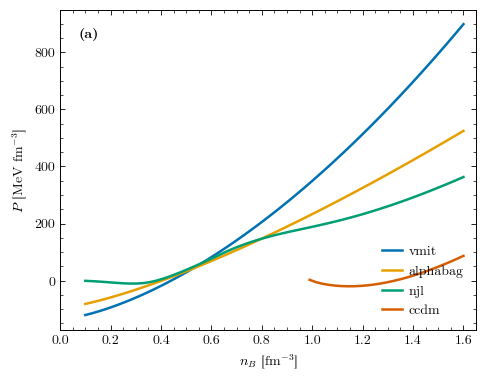

In [4]:
fig, axes = paper_grid("1x1", mode="centered", placeholder=False, aspect=1.3)
ax = axes.ravel()[0]

for (name, (matrix, n_B)), colour in zip(MATRIX.items(), OKAB_CAT):
    ax.plot(n_B, matrix["P"][0], color=colour, label=name)

ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["P"])
ax.set_xlim(0.0, 1.65)
ax.legend(loc="lower right")
panel_label(ax, "(a)")

plt.show()

### Composition

The flavour fractions and the leptons, all four models on one panel. Colour is
the SPECIES and comes from `particle_style` — u blue, d orange, s green,
electrons grey — and linestyle is the MODEL, so the two legends name four
things each instead of one legend naming sixteen. `particle_style` also
returns a linestyle, the one that marks a multiplet in a hadronic composition
figure; here the multiplet is the same for every curve and the linestyle is
needed to say which functional produced it, so only the colour is taken.

Y_e is the one that separates these models: it is the electron fraction beta
equilibrium needs to neutralize whatever charge the flavour composition leaves
over, so a phase that sits close to Y_u = Y_d = Y_s barely needs electrons at
all and one far from it needs many. Muons would appear here as a `Y_mu-`
column in `njl` and `ccdm`; the flag is off (above), so the column is zero and
is dropped by the same threshold that drops any other empty curve.

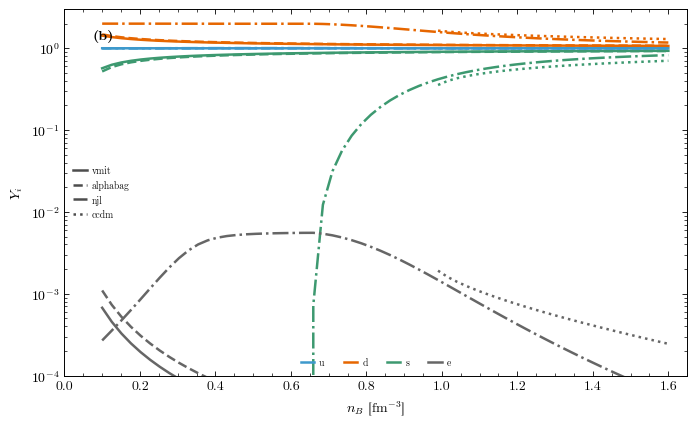

In [5]:
# Linestyle is the model. Four of them, so the legend that names the models is
# read off this dict rather than from the curves.
MODEL_STYLE = {"vmit": "-", "alphabag": "--", "njl": "-.", "ccdm": ":"}

# The row column name -> the species name `particle_style` knows.
FRACTIONS = {"Y_u": "u", "Y_d": "d", "Y_s": "s",
             "Y_e": "e", "Y_mu-": "mu-"}

# Full page width: sixteen curves and two legends do not fit a single column.
fig, axes = paper_grid("1x1", mode="double", placeholder=False, aspect=1.7)
ax = axes.ravel()[0]

for name, (matrix, n_B) in MATRIX.items():
    for column, species_name in FRACTIONS.items():
        if column not in matrix:
            continue
        fraction = matrix[column][0]
        if np.nanmax(fraction) < 1e-4:      # below the panel, not worth a colour
            continue
        colour, _ = particle_style(species_name)
        ax.plot(n_B, fraction, color=colour, ls=MODEL_STYLE[name])

ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["Y_i"])
ax.set_xlim(0.0, 1.65)
ax.set_yscale("log")
ax.set_ylim(1e-4, 3.0)
# CMU Serif has no U+2212, so matplotlib's own mathtext log labels come out as
# hollow boxes below 1. `log_decades` is figure_style's protection for exactly
# that axis and is never removed (CLAUDE.md section 10).
log_decades(ax, axis="y")

# Two legends, built from proxy lines: one says which colour is which species,
# the other which linestyle is which model.
species_keys = [plt.Line2D([], [], color=particle_style(s)[0], label=s)
                for s in ("u", "d", "s", "e")]
model_keys = [plt.Line2D([], [], color="0.3", ls=style, label=name)
              for name, style in MODEL_STYLE.items() if name in MATRIX]
ax.add_artist(ax.legend(handles=species_keys, loc="lower center", ncol=4,
                        fontsize="x-small"))
ax.legend(handles=model_keys, loc="center left", fontsize="x-small")
panel_label(ax, "(b)")

plt.show()

### Effective quark masses

The same colour-is-species, linestyle-is-model reading, and the panel shows two
genuinely different things rather than one quantity computed four ways.

* **`njl` and `ccdm` return a mass.** Their constituent masses come out of a
  gap equation solved at every point, so `M_u`, `M_d`, `M_s` are columns of the
  table and fall with density as chiral symmetry is restored. That falling
  curve is most of what those two models cost — it is why their per-point
  timings above are tens to hundreds of times the bag models'.
* **`vmit` and `alphabag` return no mass column at all.** They have no gap
  equation: the quark masses are current masses carried on the parameter
  object and are the same number at every density. What is drawn for them is
  therefore `par.m_u`, `par.m_d`, `par.m_s`, read from the parameters, and the
  flat lines are shown rather than omitted because a flat line IS the physical
  statement — alphaBag's u and d sit at exactly zero and are off the bottom of
  a log axis, which is the same statement again.

The two are not interchangeable and the panel does not pretend they are: one
set of curves is a solved quantity and the other is an input.

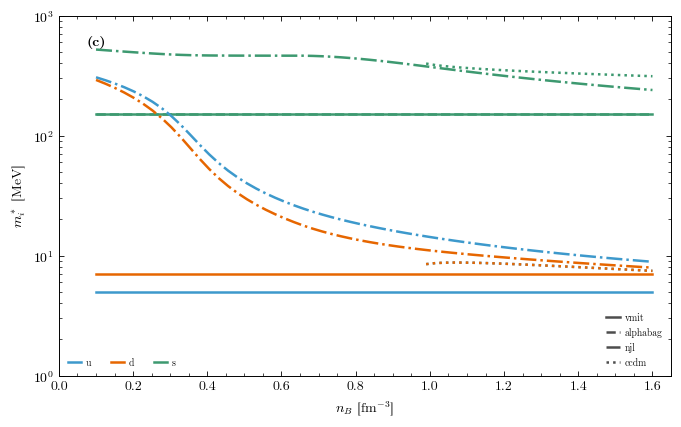

In [6]:
fig, axes = paper_grid("1x1", mode="double", placeholder=False, aspect=1.7)
ax = axes.ravel()[0]

for name, (matrix, n_B) in MATRIX.items():
    for flavour in ("u", "d", "s"):
        column = f"M_{flavour}"
        if column in matrix:
            mass = matrix[column][0]                 # solved: the gap equation
        else:
            # No gap equation in this functional; the mass is the parameter.
            mass = np.full(n_B.shape,
                           getattr(PARAMS[name], f"m_{flavour}"))
        colour, _ = particle_style(flavour)
        ax.plot(n_B, mass, color=colour, ls=MODEL_STYLE[name])

ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(r"$m^*_i$ [MeV]")
ax.set_xlim(0.0, 1.65)
ax.set_yscale("log")
ax.set_ylim(1.0, 1e3)
log_decades(ax, axis="y")

flavour_keys = [plt.Line2D([], [], color=particle_style(f)[0], label=f)
                for f in ("u", "d", "s")]
ax.add_artist(ax.legend(handles=flavour_keys, loc="lower left", ncol=3,
                        fontsize="x-small"))
ax.legend(handles=model_keys, loc="lower right", fontsize="x-small")
panel_label(ax, "(c)")

plt.show()